# Colab Transfer Learning - CIFAR10 Fake/Real

Notebook này được tối ưu để chạy trên Google Colab.

**Lưu ý:** Hãy chọn **Runtime > Change runtime type > Hardware accelerator > GPU** trước khi chạy.

## 1. Chuẩn bị Dữ liệu
Có 2 cách để chuẩn bị dữ liệu trên Colab:
1. **Cách 1**: Upload trực tiếp file `CIFAR10_Fake_Real.zip` vào thư mục bên trái của Colab.
2. **Cách 2**: Để file zip trong Google Drive và chạy cell Mount Drive dưới đây.

In [1]:
# Chạy cell này nếu fen để file zip trong Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Sau khi mount, hãy copy đường dẫn file zip từ Drive vào biến zip_path bên dưới
# Ví dụ: zip_path = '/content/drive/MyDrive/CIFAR10_Fake_Real.zip'

Mounted at /content/drive


In [2]:
import os
import zipfile

# ĐƯỜNG DẪN FILE ZIP (Sửa lại cho đúng với Drive của fen)
zip_path = '/content/drive/MyDrive/Colab Notebooks/CIFAR10_Fake_Real.zip'
extract_path = 'CIFAR10_Fake_Real'

def prepare_data(zip_path, extract_path):
    if os.path.exists(extract_path):
        print(f"Thư mục '{extract_path}' đã tồn tại. Bỏ qua giải nén.")
    elif os.path.exists(zip_path):
        print(f"Đang giải nén {zip_path}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("Giải nén thành công!")
    else:
        print("KHÔNG TÌM THẤY FILE ZIP. Hãy upload file lên Colab hoặc kiểm tra lại đường dẫn Drive.")
        return

    # Đổi tên test thành val để khớp với code training
    test_path = os.path.join(extract_path, 'test')
    val_path = os.path.join(extract_path, 'val')
    if os.path.exists(test_path):
        os.rename(test_path, val_path)
        print("Đã đổi tên 'test' thành 'val'")

prepare_data(zip_path, extract_path)

Đang giải nén /content/drive/MyDrive/Colab Notebooks/CIFAR10_Fake_Real.zip...
Giải nén thành công!
Đã đổi tên 'test' thành 'val'


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy

cudnn.benchmark = True
plt.ion()

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


In [4]:
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'CIFAR10_Fake_Real'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}

# Trên Colab có thể dùng num_workers=2 để tăng tốc
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=64,
                                             shuffle=True, num_workers=2)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print(f"Classes: {class_names}")
print(f"Dataset sizes: {dataset_sizes}")

Classes: ['FAKE', 'REAL']
Dataset sizes: {'train': 100000, 'val': 20000}


In [5]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=7, unfreeze_at=None):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        if unfreeze_at is not None and epoch == unfreeze_at:
            print("Unfreezing all layers...")
            for param in model.parameters():
                param.requires_grad = True
            optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
            scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')
    model.load_state_dict(best_model_wts)
    return model, time_elapsed, best_acc.item(), history

In [6]:
def run_experiment(strategy_name):
    print(f"\n{'='*20}")
    print(f"Running Strategy: {strategy_name}")
    print(f"{'='*20}")
    model_ft = models.resnet18(weights='DEFAULT')
    num_ftrs = model_ft.fc.in_features
    model_ft.fc = nn.Linear(num_ftrs, len(class_names))
    model_ft = model_ft.to(device)
    criterion = nn.CrossEntropyLoss()

    unfreeze_at = None
    if strategy_name == "Freeze Backbone":
        for param in model_ft.parameters():
            param.requires_grad = False
        for param in model_ft.fc.parameters():
            param.requires_grad = True
        optimizer = optim.SGD(model_ft.fc.parameters(), lr=0.001, momentum=0.9)
    elif strategy_name == "Fine-tune All":
        for param in model_ft.parameters():
            param.requires_grad = True
        optimizer = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)
    elif strategy_name == "Gradual Unfreeze":
        for param in model_ft.parameters():
            param.requires_grad = False
        for param in model_ft.fc.parameters():
            param.requires_grad = True
        optimizer = optim.SGD(model_ft.fc.parameters(), lr=0.001, momentum=0.9)
        unfreeze_at = 3 # Unfreeze sau 3 epoch cho ổn định

    exp_lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
    return train_model(model_ft, criterion, optimizer, exp_lr_scheduler, num_epochs=7, unfreeze_at=unfreeze_at)

results = {}
strategies = ["Freeze Backbone", "Fine-tune All", "Gradual Unfreeze"]

for strategy in strategies:
    _, duration, best_acc, history = run_experiment(strategy)
    results[strategy] = {'duration': duration, 'best_acc': best_acc, 'history': history}


Running Strategy: Freeze Backbone
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]


Epoch 0/6
----------
train Loss: 0.4675 Acc: 0.7750
val Loss: 0.3675 Acc: 0.8390

Epoch 1/6
----------
train Loss: 0.4452 Acc: 0.7901
val Loss: 0.3574 Acc: 0.8428

Epoch 2/6
----------
train Loss: 0.4374 Acc: 0.7946
val Loss: 0.3874 Acc: 0.8229

Epoch 3/6
----------
train Loss: 0.4350 Acc: 0.7962
val Loss: 0.3505 Acc: 0.8470

Epoch 4/6
----------
train Loss: 0.4347 Acc: 0.7966
val Loss: 0.3757 Acc: 0.8359

Epoch 5/6
----------
train Loss: 0.4357 Acc: 0.7961
val Loss: 0.3633 Acc: 0.8392

Epoch 6/6
----------
train Loss: 0.4356 Acc: 0.7953
val Loss: 0.3598 Acc: 0.8386

Training complete in 31m 42s
Best val Acc: 0.846950

Running Strategy: Fine-tune All
Epoch 0/6
----------
train Loss: 0.3069 Acc: 0.8639
val Loss: 0.1534 Acc: 0.9395

Epoch 1/6
----------
train Loss: 0.2336 Acc: 0.9020
val Loss: 0.1377 Acc: 0.9470

Epoch 2/6
----------
train Loss: 0.2085 Acc: 0.9139
val Loss: 0.1475 Acc: 0.9429

Epoch 3/6
----------
train Loss: 0.1945 Acc: 0.9194
val Loss: 0.1010 Acc: 0.9626

Epoch 4/6
---

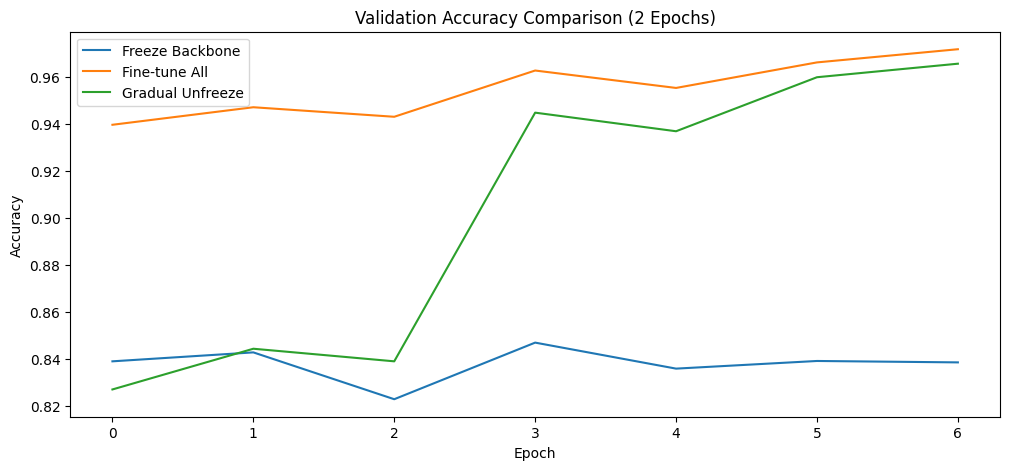


Summary Table:
Freeze Backbone | 1902.31s | Best Acc: 0.8470
Fine-tune All | 2883.95s | Best Acc: 0.9716
Gradual Unfreeze | 2440.10s | Best Acc: 0.9655


In [7]:
plt.figure(figsize=(12, 5))
for strategy in strategies:
    plt.plot(results[strategy]['history']['val_acc'], label=strategy)
plt.title('Validation Accuracy Comparison (2 Epochs)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

print("\nSummary Table:")
for s, r in results.items():
    print(f"{s} | {r['duration']:.2f}s | Best Acc: {r['best_acc']:.4f}")